# Step 1 — Import Required Libraries

In [ ]:
data-sets URL:https://www.kaggle.com/datasets/rabieelkharoua/predict-customer-purchase-behavior-dataset

# Step 2 — Load the Dataset

In [2]:
data = pd.read_csv("customer_purchase_data.csv")

data.head()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,1,66120.267939,8,0,30.568601,0,5,1
1,20,1,23579.773583,4,2,38.240097,0,5,0
2,27,1,127821.306432,11,2,31.633212,1,0,1
3,24,1,137798.623120,19,3,46.167059,0,4,1
4,31,1,99300.964220,19,1,19.823592,0,0,1


# Step 3 — Dataset Overview

In [3]:
data.shape
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1500 non-null   int64  
 1   Gender              1500 non-null   int64  
 2   AnnualIncome        1500 non-null   float64
 3   NumberOfPurchases   1500 non-null   int64  
 4   ProductCategory     1500 non-null   int64  
 5   TimeSpentOnWebsite  1500 non-null   float64
 6   LoyaltyProgram      1500 non-null   int64  
 7   DiscountsAvailed    1500 non-null   int64  
 8   PurchaseStatus      1500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 105.6 KB


,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000
mean,44.298667,0.504667,84249.164338,10.420000,2.012667,30.469040,0.326667,2.555333,0.43200
std,15.537259,0.500145,37629.493078,5.887391,1.428005,16.984392,0.469151,1.705152,0.49552
min,18.000000,0.000000,20001.512518,0.000000,0.000000,1.037023,0.000000,0.000000,0.00000
25%,31.000000,0.000000,53028.979155,5.000000,1.000000,16.156700,0.000000,1.000000,0.00000
50%,45.000000,1.000000,83699.581476,11.000000,2.000000,30.939516,0.000000,3.000000,0.00000
75%,57.000000,1.000000,117167.772858,15.000000,3.000000,44.369863,1.000000,4.000000,1.00000
max,70.000000,1.000000,149785.176481,20.000000,4.000000,59.991105,1.000000,5.000000,1.00000


# Step 4 — Check Missing Values

In [4]:
data.isnull().sum()
data = data.dropna()

# Step 5 — Check Target Variable Distribution

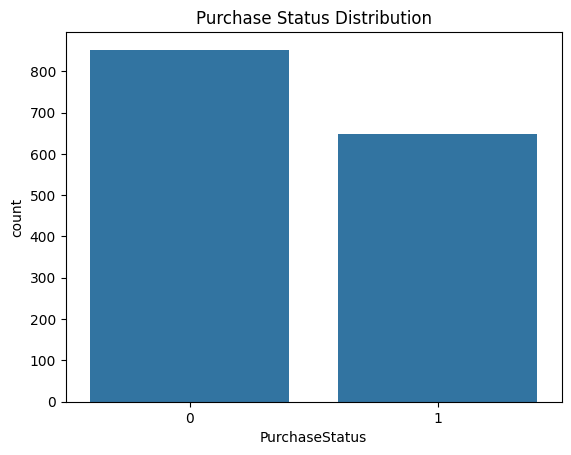

In [5]:
data['PurchaseStatus'].value_counts()

sns.countplot(x='PurchaseStatus', data=data)
plt.title("Purchase Status Distribution")
plt.show()

# Step 6 — Exploratory Data Analysis

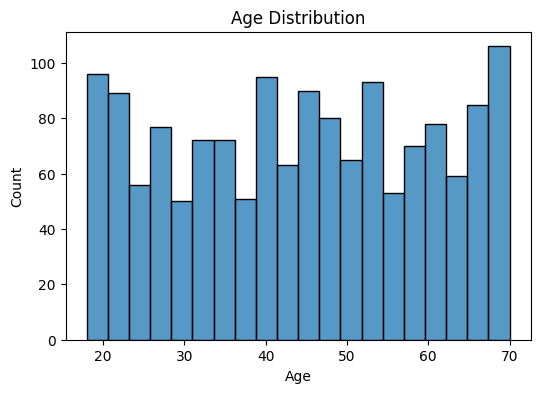

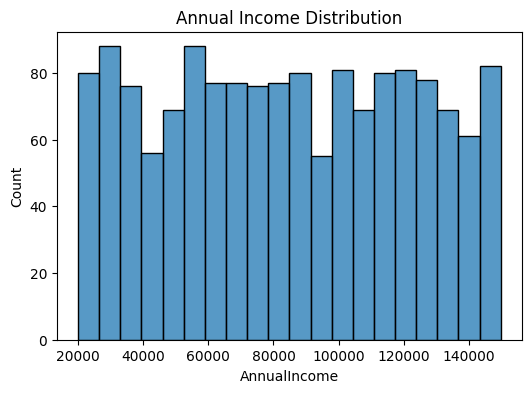

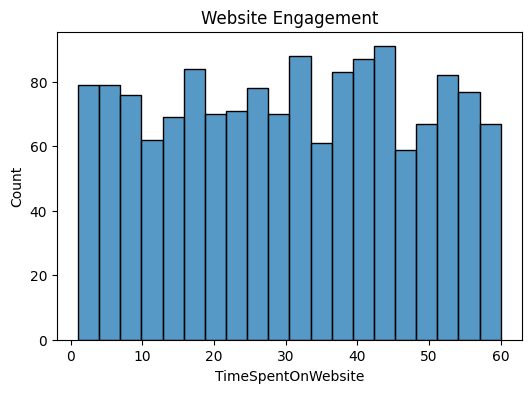

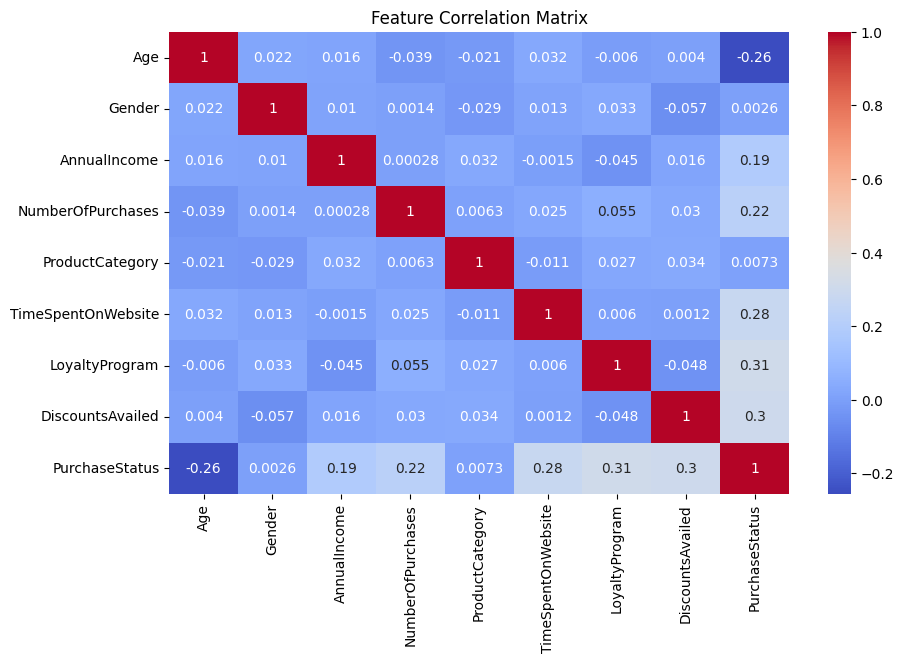

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(data['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(data['AnnualIncome'], bins=20)
plt.title("Annual Income Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(data['TimeSpentOnWebsite'], bins=20)
plt.title("Website Engagement")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

# Step 7 — Define Features and Target

In [7]:
X = data.drop("PurchaseStatus", axis=1)
y = data["PurchaseStatus"]

# Step 8 — Train Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 9 — Feature Scaling

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 10 — Logistic Regression Model

In [10]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.8366666666666667
              precision    recall  f1-score   support

           0       0.82      0.92      0.87       172
           1       0.88      0.72      0.79       128

    accuracy                           0.84       300
   macro avg       0.85      0.82      0.83       300
weighted avg       0.84      0.84      0.83       300



# Step 11 — Decision Tree Model

In [11]:
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.9066666666666666
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       172
           1       0.94      0.84      0.88       128

    accuracy                           0.91       300
   macro avg       0.91      0.90      0.90       300
weighted avg       0.91      0.91      0.91       300



# Step 12 — Random Forest Model

In [12]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       172
           1       0.97      0.91      0.94       128

    accuracy                           0.95       300
   macro avg       0.95      0.94      0.95       300
weighted avg       0.95      0.95      0.95       300



# Step 13 — Support Vector Machine Model

In [13]:
svm_model = SVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.87
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       172
           1       0.89      0.80      0.84       128

    accuracy                           0.87       300
   macro avg       0.87      0.86      0.87       300
weighted avg       0.87      0.87      0.87       300



# Step 14 — Confusion Matrix

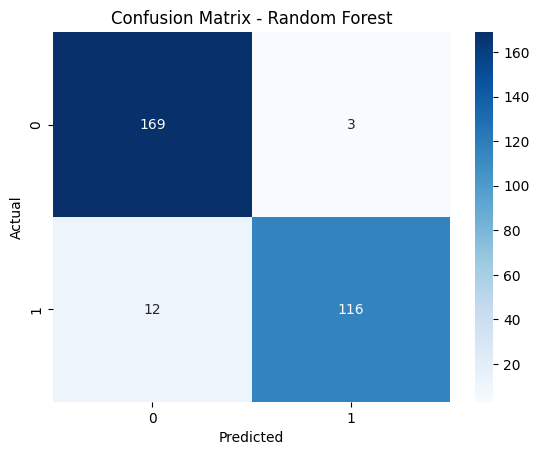

In [14]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 15 — Model Comparison

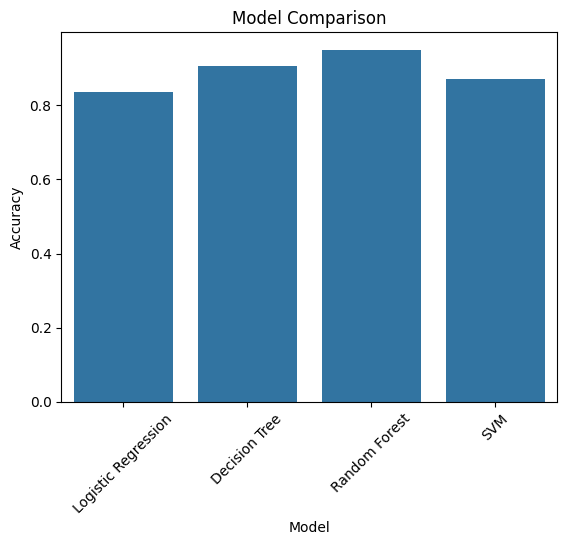

In [15]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest","SVM"],
    "Accuracy":[
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

results

sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()

# Step 16 — Feature Importance

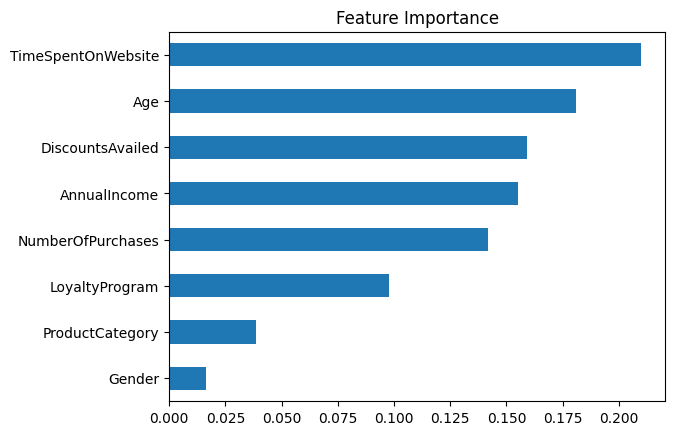

In [16]:
importances = rf_model.feature_importances_

features = data.drop("PurchaseStatus", axis=1).columns

feature_importance = pd.Series(importances, index=features)

feature_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

# Step 17 — Final Model Prediction

In [17]:
sample_customer = X_test[0].reshape(1,-1)

prediction = rf_model.predict(sample_customer)

print("Predicted Purchase:", prediction)

Predicted Purchase: [1]


# Step 18 — Save the Model

In [19]:
import joblib

joblib.dump(rf_model, "purchase_prediction_model.pkl")

['purchase_prediction_model.pkl']

# Step 19 — Hyperparameter Tuning

In [20]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_rf = grid_search.best_estimator_

best_predictions = best_rf.predict(X_test)

print("Optimised Random Forest Accuracy:",
      accuracy_score(y_test, best_predictions))

Best Parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
Optimised Random Forest Accuracy: 0.9366666666666666


# Step 20 — Feature Importance Analysis

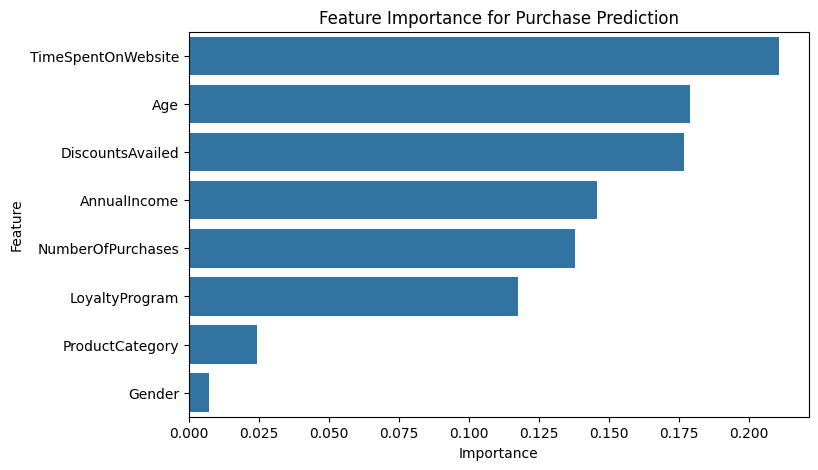

In [21]:
importances = best_rf.feature_importances_

features = data.drop("PurchaseStatus", axis=1).columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df

plt.figure(figsize=(8,5))

sns.barplot(x="Importance", y="Feature", data=importance_df)

plt.title("Feature Importance for Purchase Prediction")

plt.show()